In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.6/718.6 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.0 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 10.2 MB/s eta 0:00:00


In [ ]:
locations = {
    "Thanjavur": {"lat": 10.7852, "lon": 79.1391},
    "Nilgiris": {"lat": 11.4916, "lon": 76.7337},
    "Chennai": {"lat": 13.0827, "lon": 80.2707},
    "Virudhunagar": {"lat": 9.5680, "lon": 77.9624},
    "Nagapattinam": {"lat": 10.7656, "lon": 79.8428},
}

In [ ]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# Setup API client
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Locations
locations = {
    "Thanjavur": {"lat": 10.7852, "lon": 79.1391},
    "Nilgiris": {"lat": 11.4916, "lon": 76.7337},
    "Chennai": {"lat": 13.0827, "lon": 80.2707},
    "Virudhunagar": {"lat": 9.5680, "lon": 77.9624},
    "Nagapattinam": {"lat": 10.7656, "lon": 79.8428},
}

# API URL
url = "https://archive-api.open-meteo.com/v1/archive"

# Store all data
all_dataframes = []

for district, coord in locations.items():
    print(f"Fetching data for {district}...")

    params = {
        "latitude": coord["lat"],
        "longitude": coord["lon"],
        "start_date": "2020-01-01",
        "end_date": "2025-12-31",
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "relative_humidity_2m_mean",
            "precipitation_sum",
            "wind_speed_10m_max",
            "soil_moisture_0_to_7cm_mean"
        ],
        "timezone": "auto",
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]

    daily = response.Daily()

    # Extract variables
    data = {
        "date": pd.date_range(
            start=pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit="s", utc=True),
            end=pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=daily.Interval()),
            inclusive="left"
        ),
        "temperature_mean": daily.Variables(0).ValuesAsNumpy(),
        "temperature_max": daily.Variables(1).ValuesAsNumpy(),
        "temperature_min": daily.Variables(2).ValuesAsNumpy(),
        "humidity": daily.Variables(3).ValuesAsNumpy(),
        "rainfall": daily.Variables(4).ValuesAsNumpy(),
        "wind_speed": daily.Variables(5).ValuesAsNumpy(),
        "soil_moisture": daily.Variables(6).ValuesAsNumpy(),
    }

    df = pd.DataFrame(data)

    # Add district column
    df["district"] = district

    all_dataframes.append(df)

# Combine all districts
final_df = pd.concat(all_dataframes, ignore_index=True)

# Sort for time-series consistency
final_df = final_df.sort_values(by=["district", "date"])

# Save to CSV
final_df.to_csv("tamilnadu_weather_2020_2025.csv", index=False)

print("\nSaved successfully: tamilnadu_weather_2020_2025.csv")
print(final_df.head())

Fetching data for Thanjavur...
Fetching data for Nilgiris...
Fetching data for Chennai...
Fetching data for Virudhunagar...
Fetching data for Nagapattinam...

Saved successfully: tamilnadu_weather_2020_2025.csv
                          date  temperature_mean  temperature_max  \
4384 2020-01-01 00:00:00+00:00         25.047918        26.900000   
4385 2020-01-02 00:00:00+00:00         25.502083        27.299999   
4386 2020-01-03 00:00:00+00:00         26.147913        28.700001   
4387 2020-01-04 00:00:00+00:00         26.358332        28.750000   
4388 2020-01-05 00:00:00+00:00         26.104170        27.600000   

      temperature_min   humidity  rainfall  wind_speed  soil_moisture district  
4384        23.750000  87.857361  6.600000   13.684735       0.368083  Chennai  
4385        23.700001  88.324951  2.300000   11.592895       0.362208  Chennai  
4386        23.549999  84.923759  1.600000   11.770403       0.350708  Chennai  
4387        23.650000  84.767128  0.400000   12.81

In [ ]:
len(final_df)

10960

In [ ]:
import pandas as pd
import numpy as np

# Load your CSV
df = pd.read_csv("tamilnadu_weather_2020_2025.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Sort (VERY IMPORTANT)
df = df.sort_values(by=["district", "date"]).reset_index(drop=True)

print(df.head())

                       date  temperature_mean  temperature_max  \
0 2020-01-01 00:00:00+00:00         25.047918            26.90   
1 2020-01-02 00:00:00+00:00         25.502083            27.30   
2 2020-01-03 00:00:00+00:00         26.147913            28.70   
3 2020-01-04 00:00:00+00:00         26.358332            28.75   
4 2020-01-05 00:00:00+00:00         26.104170            27.60   

   temperature_min  humidity  rainfall  wind_speed  soil_moisture district  
0            23.75  87.85736  6.600000   13.684735       0.368083  Chennai  
1            23.70  88.32495  2.300000   11.592895       0.362208  Chennai  
2            23.55  84.92376  1.600000   11.770403       0.350708  Chennai  
3            23.65  84.76713  0.400000   12.819235       0.334292  Chennai  
4            24.65  84.26856  5.299999   11.592894       0.351375  Chennai  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10960 entries, 0 to 10959
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   date              10960 non-null  datetime64[ns, UTC]
 1   temperature_mean  10960 non-null  float64            
 2   temperature_max   10960 non-null  float64            
 3   temperature_min   10960 non-null  float64            
 4   humidity          10960 non-null  float64            
 5   rainfall          10960 non-null  float64            
 6   wind_speed        10960 non-null  float64            
 7   soil_moisture     10960 non-null  float64            
 8   district          10960 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(7), object(1)
memory usage: 770.8+ KB


In [ ]:
def add_rolling_features(df):
    df = df.copy()

    for district in df["district"].unique():
        mask = df["district"] == district

        # Temperature rolling
        df.loc[mask, "temp_avg_3d"] = df.loc[mask, "temperature_mean"].rolling(3).mean()
        df.loc[mask, "temp_avg_5d"] = df.loc[mask, "temperature_mean"].rolling(5).mean()

        # Humidity
        df.loc[mask, "humidity_avg_3d"] = df.loc[mask, "humidity"].rolling(3).mean()
        df.loc[mask, "humidity_avg_5d"] = df.loc[mask, "humidity"].rolling(5).mean()

        # Rainfall
        df.loc[mask, "rainfall_sum_3d"] = df.loc[mask, "rainfall"].rolling(3).sum()
        df.loc[mask, "rainfall_sum_5d"] = df.loc[mask, "rainfall"].rolling(5).sum()

    return df

df = add_rolling_features(df)

In [ ]:
df.head()

,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,soil_moisture,district,temp_avg_3d,temp_avg_5d,humidity_avg_3d,humidity_avg_5d,rainfall_sum_3d,rainfall_sum_5d
0,2020-01-01 00:00:00+00:00,25.047918,26.90,23.75,87.85736,6.600000,13.684735,0.368083,Chennai,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02 00:00:00+00:00,25.502083,27.30,23.70,88.32495,2.300000,11.592895,0.362208,Chennai,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03 00:00:00+00:00,26.147913,28.70,23.55,84.92376,1.600000,11.770403,0.350708,Chennai,25.565971,NaN,87.035357,NaN,10.500000,NaN
3,2020-01-04 00:00:00+00:00,26.358332,28.75,23.65,84.76713,0.400000,12.819235,0.334292,Chennai,26.002776,NaN,86.005280,NaN,4.300000,NaN
4,2020-01-05 00:00:00+00:00,26.104170,27.60,24.65,84.26856,5.299999,11.592894,0.351375,Chennai,26.203472,25.832083,84.653150,86.028352,7.299999,16.199999


In [ ]:
df["temp_humidity"] = df["temperature_mean"] * df["humidity"]
df["rainfall_humidity"] = df["rainfall"] * df["humidity"]

In [ ]:
df["month"] = df["date"].dt.month
df["day_of_year"] = df["date"].dt.dayofyear

In [ ]:
def generate_labels(df):
    df = df.copy()

    # Initialize
    df["leaf_blast_risk"] = 0
    df["brown_spot_risk"] = 0
    df["blb_risk"] = 0
    df["tungro_risk"] = 0

    # ---- Leaf Blast ----
    cond_high = (
        (df["humidity_avg_3d"] > 85) &
        (df["temp_avg_3d"].between(20, 28)) &
        (df["rainfall_sum_3d"] > 5)
    )
    cond_med = (
        (df["humidity"] > 75) &
        (df["temperature_mean"].between(18, 30))
    )

    df.loc[cond_high, "leaf_blast_risk"] = 2
    df.loc[~cond_high & cond_med, "leaf_blast_risk"] = 1

    # ---- Brown Spot ----
    cond_high = (
        (df["temp_avg_3d"] > 30) &
        (df["rainfall_sum_5d"] < 5)
    )
    cond_med = (df["temperature_mean"] > 28)

    df.loc[cond_high, "brown_spot_risk"] = 2
    df.loc[~cond_high & cond_med, "brown_spot_risk"] = 1

    # ---- BLB ----
    cond_high = (
        (df["rainfall_sum_3d"] > 10) &
        (df["wind_speed"] > 20) &
        (df["temperature_mean"] > 25)
    )
    cond_med = (df["rainfall"] > 5)

    df.loc[cond_high, "blb_risk"] = 2
    df.loc[~cond_high & cond_med, "blb_risk"] = 1

    # ---- Tungro ----
    cond_high = (
        (df["humidity_avg_5d"] > 80) &
        (df["temperature_mean"].between(25, 32))
    )
    cond_med = (df["humidity"] > 70)

    df.loc[cond_high, "tungro_risk"] = 2
    df.loc[~cond_high & cond_med, "tungro_risk"] = 1

    return df

df = generate_labels(df)

In [ ]:
df.head()

,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,soil_moisture,district,temp_avg_3d,...,rainfall_sum_3d,rainfall_sum_5d,temp_humidity,rainfall_humidity,month,day_of_year,leaf_blast_risk,brown_spot_risk,blb_risk,tungro_risk
0,2020-01-01 00:00:00+00:00,25.047918,26.90,23.75,87.85736,6.600000,13.684735,0.368083,Chennai,NaN,...,NaN,NaN,2200.643949,579.858576,1,1,1,0,1,1
1,2020-01-02 00:00:00+00:00,25.502083,27.30,23.70,88.32495,2.300000,11.592895,0.362208,Chennai,NaN,...,NaN,NaN,2252.470206,203.147385,1,2,1,0,0,1
2,2020-01-03 00:00:00+00:00,26.147913,28.70,23.55,84.92376,1.600000,11.770403,0.350708,Chennai,25.565971,...,10.500000,NaN,2220.579088,135.878016,1,3,2,0,0,1
3,2020-01-04 00:00:00+00:00,26.358332,28.75,23.65,84.76713,0.400000,12.819235,0.334292,Chennai,26.002776,...,4.300000,NaN,2234.320155,33.906852,1,4,1,0,0,1
4,2020-01-05 00:00:00+00:00,26.104170,27.60,24.65,84.26856,5.299999,11.592894,0.351375,Chennai,26.203472,...,7.299999,16.199999,2199.760816,446.623284,1,5,1,0,1,2


In [ ]:
risk_columns = ['leaf_blast_risk', 'brown_spot_risk', 'blb_risk', 'tungro_risk']

for col in risk_columns:
    print(f"\nUnique value counts for {col}:")
    print(df[col].value_counts())



Unique value counts for leaf_blast_risk:
leaf_blast_risk
0    7095
1    3155
2     710
Name: count, dtype: int64

Unique value counts for brown_spot_risk:
brown_spot_risk
0    6108
1    3403
2    1449
Name: count, dtype: int64

Unique value counts for blb_risk:
blb_risk
0    8323
1    2161
2     476
Name: count, dtype: int64

Unique value counts for tungro_risk:
tungro_risk
1    5464
0    3975
2    1521
Name: count, dtype: int64


In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
df.head()

,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,soil_moisture,district,temp_avg_3d,...,rainfall_sum_3d,rainfall_sum_5d,temp_humidity,rainfall_humidity,month,day_of_year,leaf_blast_risk,brown_spot_risk,blb_risk,tungro_risk
0,2020-01-05 00:00:00+00:00,26.104170,27.60,24.65,84.26856,5.299999,11.592894,0.351375,Chennai,26.203472,...,7.299999,16.199999,2199.760816,446.623284,1,5,1,0,1,2
1,2020-01-06 00:00:00+00:00,25.610418,26.85,23.90,85.08052,3.999999,17.873556,0.356292,Chennai,26.024307,...,9.699998,13.599998,2178.947681,340.322037,1,6,1,0,0,2
2,2020-01-07 00:00:00+00:00,25.966665,27.90,24.30,79.31052,2.200000,22.007162,0.349750,Chennai,25.893751,...,11.499999,13.499999,2059.429704,174.483168,1,7,1,0,2,2
3,2020-01-08 00:00:00+00:00,25.422913,27.75,23.80,74.56400,0.100000,14.658676,0.330542,Chennai,25.666665,...,6.300000,11.999999,1895.634085,7.456400,1,8,0,0,0,2
4,2020-01-09 00:00:00+00:00,24.618752,27.45,21.45,73.84547,0.000000,10.483357,0.312125,Chennai,25.336110,...,2.300000,11.599999,1817.983312,0.000000,1,9,0,0,0,1


In [ ]:
df = pd.get_dummies(df, columns=["district"])

In [ ]:
df.head()

,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,soil_moisture,temp_avg_3d,temp_avg_5d,...,day_of_year,leaf_blast_risk,brown_spot_risk,blb_risk,tungro_risk,district_Chennai,district_Nagapattinam,district_Nilgiris,district_Thanjavur,district_Virudhunagar
0,2020-01-05 00:00:00+00:00,26.104170,27.60,24.65,84.26856,5.299999,11.592894,0.351375,26.203472,25.832083,...,5,1,0,1,2,True,False,False,False,False
1,2020-01-06 00:00:00+00:00,25.610418,26.85,23.90,85.08052,3.999999,17.873556,0.356292,26.024307,25.944583,...,6,1,0,0,2,True,False,False,False,False
2,2020-01-07 00:00:00+00:00,25.966665,27.90,24.30,79.31052,2.200000,22.007162,0.349750,25.893751,26.037500,...,7,1,0,2,2,True,False,False,False,False
3,2020-01-08 00:00:00+00:00,25.422913,27.75,23.80,74.56400,0.100000,14.658676,0.330542,25.666665,25.892500,...,8,0,0,0,2,True,False,False,False,False
4,2020-01-09 00:00:00+00:00,24.618752,27.45,21.45,73.84547,0.000000,10.483357,0.312125,25.336110,25.544584,...,9,0,0,0,1,True,False,False,False,False


In [ ]:
feature_cols = [
    "temperature_mean", "temperature_max", "temperature_min",
    "humidity", "rainfall", "wind_speed",
    "temp_avg_3d", "temp_avg_5d",
    "humidity_avg_3d", "humidity_avg_5d",
    "rainfall_sum_3d", "rainfall_sum_5d",
    "temp_humidity", "rainfall_humidity",
    "month", "day_of_year"
] + [col for col in df.columns if "district_" in col]

target_cols = [
    "leaf_blast_risk",
    "brown_spot_risk",
    "blb_risk",
    "tungro_risk"
]

In [ ]:
WINDOW_SIZE = 7

def create_sequences(df, feature_cols, target_cols):
    X, y = [], []

    data = df[feature_cols + target_cols].values

    for i in range(len(data) - WINDOW_SIZE):
        X.append(data[i:i+WINDOW_SIZE, :len(feature_cols)])
        y.append(data[i+WINDOW_SIZE, len(feature_cols):])

    return np.array(X), np.array(y)

X, y = create_sequences(df, feature_cols, target_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10933, 7, 21)
y shape: (10933, 4)


In [ ]:
split_ratio = 0.8
split = int(len(X) * split_ratio)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8746, 7, 21)
Test: (2187, 7, 21)


In [ ]:
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("Saved processed datasets")

Saved processed datasets


In [ ]:
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

In [ ]:
# Ensure integer labels
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Remove any NaN rows
mask_train = ~np.isnan(y_train).any(axis=1)
mask_test = ~np.isnan(y_test).any(axis=1)

X_train_rf = X_train_rf[mask_train]
y_train = y_train[mask_train]

X_test_rf = X_test_rf[mask_test]
y_test = y_test[mask_test]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_rf = MultiOutputClassifier(rf)
model_rf.fit(X_train_rf, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                       n_estimators=150,
                                                       n_jobs=-1,
                                                       random_state=42))

In [ ]:
y_pred_rf = model_rf.predict(X_test_rf)

for i, disease in enumerate(["Leaf Blast", "Brown Spot", "BLB", "Tungro"]):
    print(f"\n--- {disease} ---")
    print(classification_report(y_test[:, i], y_pred_rf[:, i]))


--- Leaf Blast ---
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1689
           1       0.66      0.73      0.69       402
           2       0.79      0.82      0.81        96

    accuracy                           0.88      2187
   macro avg       0.80      0.82      0.81      2187
weighted avg       0.89      0.88      0.88      2187


--- Brown Spot ---
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       833
           1       0.81      0.88      0.84       838
           2       0.88      0.92      0.90       516

    accuracy                           0.87      2187
   macro avg       0.88      0.88      0.88      2187
weighted avg       0.88      0.87      0.87      2187


--- BLB ---
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1695
           1       0.66      0.34      0.45       437
           2       0.0

In [ ]:
import numpy as np

importances = model_rf.estimators_[0].feature_importances_
print("Top features:", np.argsort(importances)[-10:])

Top features: [139 133 127 113 135 126 108 138 134 129]


In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

model_xgb = MultiOutputClassifier(xgb)
model_xgb.fit(X_train_rf, y_train)

MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.05, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=6,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None, ...))

In [ ]:
y_pred_xgb = model_xgb.predict(X_test_rf)

for i, disease in enumerate(["Leaf Blast", "Brown Spot", "BLB", "Tungro"]):
    print(f"\n--- {disease} ---")
    print(classification_report(y_test[:, i], y_pred_xgb[:, i]))


--- Leaf Blast ---
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1689
           1       0.67      0.74      0.70       402
           2       0.78      0.86      0.82        96

    accuracy                           0.88      2187
   macro avg       0.80      0.84      0.82      2187
weighted avg       0.89      0.88      0.89      2187


--- Brown Spot ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       833
           1       0.83      0.85      0.84       838
           2       0.88      0.92      0.90       516

    accuracy                           0.88      2187
   macro avg       0.88      0.88      0.88      2187
weighted avg       0.88      0.88      0.88      2187


--- BLB ---
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1695
           1       0.61      0.39      0.48       437
           2       0.5

In [ ]:
import numpy as np

X_train = np.load("X_train.npy", allow_pickle=True)
X_test = np.load("X_test.npy", allow_pickle=True)
y_train = np.load("y_train.npy", allow_pickle=True)
y_test = np.load("y_test.npy", allow_pickle=True)

print(X_train.shape, y_train.shape)


(8746, 7, 21) (8746, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Flatten → scale → reshape back
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape)

Shapes:
X_train: (8746, 7, 21)
y_train: (8746, 4)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 7, 21)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     22,016 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaf_blast (Dense)  │ (None, 3)         │         99 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ brown_spot (Dense)  │ (None, 3)         │         99 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ blb (Dense)         │ (None, 3)         │         99 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tungro (Dense)      │ (None, 3)         │         99 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,492 (95.67 KB)

 Trainable params: 24,492 (95.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - blb_accuracy: 0.7414 - blb_loss: 0.6128 - brown_spot_accuracy: 0.8182 - brown_spot_loss: 0.4524 - leaf_blast_accuracy: 0.7166 - leaf_blast_loss: 0.6195 - loss: 2.2943 - tungro_accuracy: 0.7375 - tungro_loss: 0.6097 - val_blb_accuracy: 0.8029 - val_blb_loss: 0.5216 - val_brown_spot_accuracy: 0.7220 - val_brown_spot_loss: 0.5675 - val_leaf_blast_accuracy: 0.8596 - val_leaf_blast_loss: 0.3330 - val_loss: 1.8745 - val_tungro_accuracy: 0.8102 - val_tungro_loss: 0.4467
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - blb_accuracy: 0.7914 - blb_loss: 0.5123 - brown_spot_accuracy: 0.8740 - brown_spot_loss: 0.2916 - leaf_blast_accuracy: 0.7951 - leaf_blast_loss: 0.4721 - loss: 1.7298 - tungro_accuracy: 0.8048 - tungro_loss: 0.4531 - val_blb_accuracy: 0.8080 - val_blb_loss: 0.4996 - val_brown_spot_accuracy: 0.7435 - val_brown_spot_loss: 0.5271 - val_leaf_blast_accuracy: 0.8679 - val_leaf_blast_loss: 0.2909 - val_loss: 1.7025 - val_tung

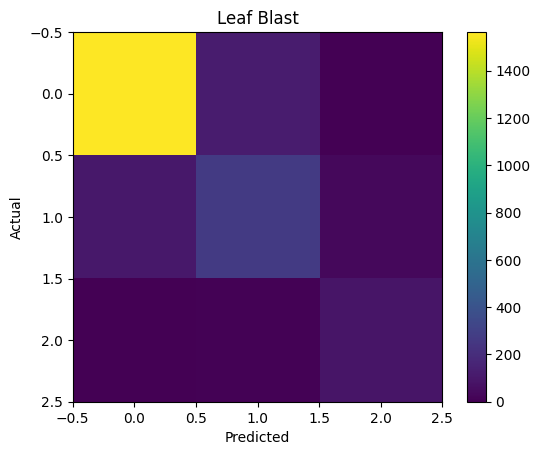

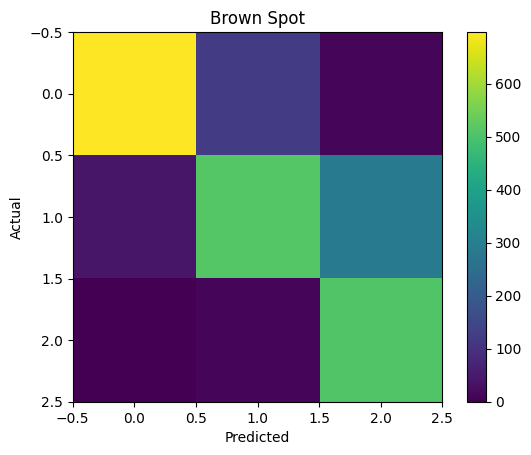

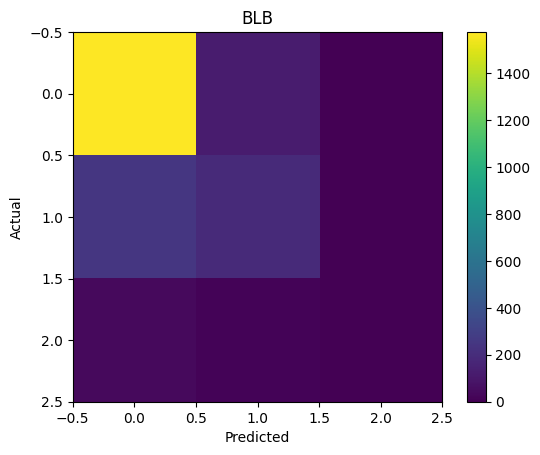

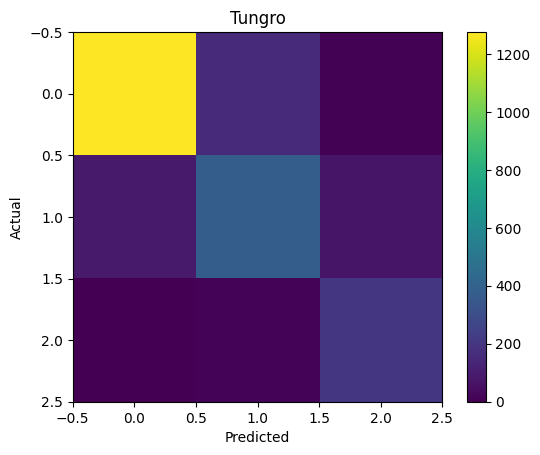

Model saved successfully


In [ ]:
# ================================
# 1. IMPORTS
# ================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ================================
# 2. LOAD DATA
# ================================
X_train = np.load("X_train.npy",allow_pickle=True)
X_train = np.load("X_train.npy",allow_pickle=True)
X_test = np.load("X_test.npy",allow_pickle=True)
y_train = np.load("y_train.npy",allow_pickle=True)
y_test = np.load("y_test.npy",allow_pickle=True)



# FIX TYPES
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)

print("Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# ================================
# 3. SCALE FEATURES
# ================================
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_2d).reshape(X_test.shape)

# ================================
# 4. SPLIT LABELS (MULTI-OUTPUT)
# ================================
y_train_split = [
    y_train[:, 0],
    y_train[:, 1],
    y_train[:, 2],
    y_train[:, 3],
]

y_test_split = [
    y_test[:, 0],
    y_test[:, 1],
    y_test[:, 2],
    y_test[:, 3],
]

# ================================
# 5. BUILD MODEL (MULTI-HEAD LSTM)
# ================================
inputs = layers.Input(shape=(X_train.shape[1], X_train.shape[2]))

x = layers.LSTM(64)(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)

leaf_blast = layers.Dense(3, activation="softmax", name="leaf_blast")(x)
brown_spot = layers.Dense(3, activation="softmax", name="brown_spot")(x)
blb = layers.Dense(3, activation="softmax", name="blb")(x)
tungro = layers.Dense(3, activation="softmax", name="tungro")(x)

model = Model(inputs=inputs, outputs=[leaf_blast, brown_spot, blb, tungro])

# ================================
# 6. COMPILE
# ================================
model.compile(
    optimizer="adam",
    loss={
        "leaf_blast": "sparse_categorical_crossentropy",
        "brown_spot": "sparse_categorical_crossentropy",
        "blb": "sparse_categorical_crossentropy",
        "tungro": "sparse_categorical_crossentropy",
    },
    metrics={
        "leaf_blast": ["accuracy"],
        "brown_spot": ["accuracy"],
        "blb": ["accuracy"],
        "tungro": ["accuracy"],
    }
)

model.summary()

# ================================
# 7. TRAIN
# ================================
history = model.fit(
    X_train_scaled,
    {
        "leaf_blast": y_train_split[0],
        "brown_spot": y_train_split[1],
        "blb": y_train_split[2],
        "tungro": y_train_split[3],
    },
    validation_data=(
        X_test_scaled,
        {
            "leaf_blast": y_test_split[0],
            "brown_spot": y_test_split[1],
            "blb": y_test_split[2],
            "tungro": y_test_split[3],
        }
    ),
    epochs=20,
    batch_size=32
)

# ================================
# 8. PREDICT
# ================================
preds = model.predict(X_test_scaled)

# Convert probabilities → class labels
y_pred = [np.argmax(p, axis=1) for p in preds]

# ================================
# 9. EVALUATION
# ================================
diseases = ["Leaf Blast", "Brown Spot", "BLB", "Tungro"]

for i in range(4):
    print(f"\n--- {diseases[i]} ---")
    print(classification_report(y_test[:, i], y_pred[i]))

# ================================
# 10. ACCURACY PER DISEASE
# ================================
for i in range(4):
    acc = np.mean(y_pred[i] == y_test[:, i])
    print(f"{diseases[i]} Accuracy: {acc:.4f}")

# ================================
# 11. CONFUSION MATRIX
# ================================
for i in range(4):
    cm = confusion_matrix(y_test[:, i], y_pred[i])

    plt.figure()
    plt.imshow(cm)
    plt.title(diseases[i])
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ================================
# 12. SAVE MODEL
# ================================
model.save("paddy_lstm_multi_output.h5")
print("Model saved successfully")

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train))

(8746, 7, 21)
(8746, 4)
[0 1 2]


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 7, 21)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │     16,704 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaf_blast (Dense)  │ (None, 3)         │         99 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ brown_spot (Dense)  │ (None, 3)         │         99 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ blb (Dense)         │ (None, 3)         │         99 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tungro (Dense)      │ (None, 3)         │         99 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,180 (74.92 KB)

 Trainable params: 19,180 (74.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - blb_accuracy: 0.7661 - blb_loss: 0.5895 - brown_spot_accuracy: 0.8126 - brown_spot_loss: 0.4311 - leaf_blast_accuracy: 0.7514 - leaf_blast_loss: 0.5652 - loss: 2.1621 - tungro_accuracy: 0.7483 - tungro_loss: 0.5757 - val_blb_accuracy: 0.7984 - val_blb_loss: 0.5167 - val_brown_spot_accuracy: 0.6859 - val_brown_spot_loss: 0.6620 - val_leaf_blast_accuracy: 0.8509 - val_leaf_blast_loss: 0.3396 - val_loss: 1.9317 - val_tungro_accuracy: 0.8235 - val_tungro_loss: 0.4040
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - blb_accuracy: 0.7971 - blb_loss: 0.5020 - brown_spot_accuracy: 0.8705 - brown_spot_loss: 0.2834 - leaf_blast_accuracy: 0.8051 - leaf_blast_loss: 0.4473 - loss: 1.6601 - tungro_accuracy: 0.8140 - tungro_loss: 0.4280 - val_blb_accuracy: 0.8006 - val_blb_loss: 0.5170 - val_brown_spot_accuracy: 0.6918 - val_brown_spot_loss: 0.6530 - val_leaf_blast_accuracy: 0.8468 - val_leaf_blast_loss: 0.3277 - val_loss: 1.8929 - val_tungr

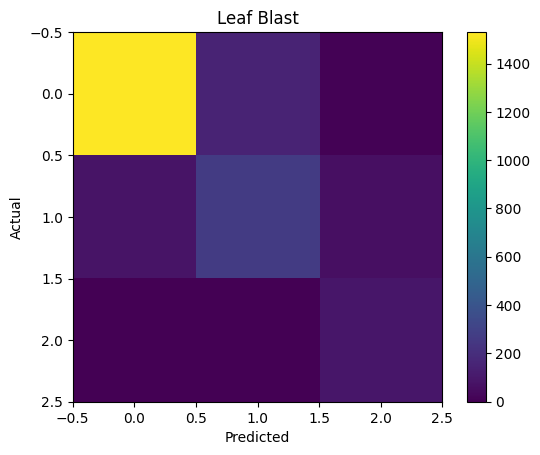

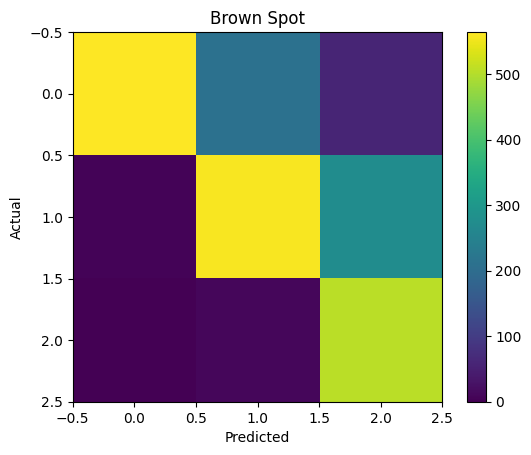

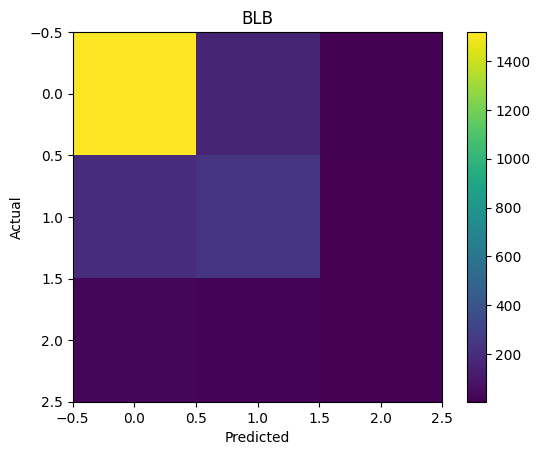

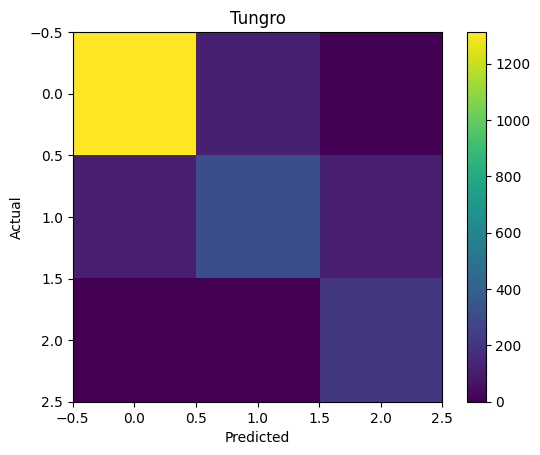

Model saved successfully


In [ ]:
# ================================
# 5. BUILD MODEL (MULTI-HEAD LSTM)
# ================================
inputs = layers.Input(shape=(X_train.shape[1], X_train.shape[2]))

x = layers.GRU(64)(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)

leaf_blast = layers.Dense(3, activation="softmax", name="leaf_blast")(x)
brown_spot = layers.Dense(3, activation="softmax", name="brown_spot")(x)
blb = layers.Dense(3, activation="softmax", name="blb")(x)
tungro = layers.Dense(3, activation="softmax", name="tungro")(x)

model = Model(inputs=inputs, outputs=[leaf_blast, brown_spot, blb, tungro])

# ================================
# 6. COMPILE
# ================================
model.compile(
    optimizer="adam",
    loss={
        "leaf_blast": "sparse_categorical_crossentropy",
        "brown_spot": "sparse_categorical_crossentropy",
        "blb": "sparse_categorical_crossentropy",
        "tungro": "sparse_categorical_crossentropy",
    },
    metrics={
        "leaf_blast": ["accuracy"],
        "brown_spot": ["accuracy"],
        "blb": ["accuracy"],
        "tungro": ["accuracy"],
    }
)

model.summary()

# ================================
# 7. TRAIN
# ================================
history = model.fit(
    X_train_scaled,
    {
        "leaf_blast": y_train_split[0],
        "brown_spot": y_train_split[1],
        "blb": y_train_split[2],
        "tungro": y_train_split[3],
    },
    validation_data=(
        X_test_scaled,
        {
            "leaf_blast": y_test_split[0],
            "brown_spot": y_test_split[1],
            "blb": y_test_split[2],
            "tungro": y_test_split[3],
        }
    ),
    epochs=20,
    batch_size=32
)

# ================================
# 8. PREDICT
# ================================
preds = model.predict(X_test_scaled)

# Convert probabilities → class labels
y_pred = [np.argmax(p, axis=1) for p in preds]

# ================================
# 9. EVALUATION
# ================================
diseases = ["Leaf Blast", "Brown Spot", "BLB", "Tungro"]

for i in range(4):
    print(f"\n--- {diseases[i]} ---")
    print(classification_report(y_test[:, i], y_pred[i]))

# ================================
# 10. ACCURACY PER DISEASE
# ================================
for i in range(4):
    acc = np.mean(y_pred[i] == y_test[:, i])
    print(f"{diseases[i]} Accuracy: {acc:.4f}")

# ================================
# 11. CONFUSION MATRIX
# ================================
for i in range(4):
    cm = confusion_matrix(y_test[:, i], y_pred[i])

    plt.figure()
    plt.imshow(cm)
    plt.title(diseases[i])
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ================================
# 12. SAVE MODEL
# ================================
model.save("paddy_gnn_multi_output.h5")
print("Model saved successfully")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 7, 21)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 5, 64)     │      4,096 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 3, 64)     │     12,352 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaf_blast (Dense)  │ (None, 3)         │        195 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ brown_spot (Dense)  │ (None, 3)         │        195 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ blb (Dense)         │ (None, 3)         │        195 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tungro (Dense)      │ (None, 3)         │        195 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,388 (83.55 KB)

 Trainable params: 21,388 (83.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - blb_accuracy: 0.7320 - blb_loss: 0.6352 - brown_spot_accuracy: 0.8139 - brown_spot_loss: 0.4433 - leaf_blast_accuracy: 0.7169 - leaf_blast_loss: 0.6257 - loss: 2.3361 - tungro_accuracy: 0.7243 - tungro_loss: 0.6320 - val_blb_accuracy: 0.7952 - val_blb_loss: 0.5594 - val_brown_spot_accuracy: 0.7298 - val_brown_spot_loss: 0.5880 - val_leaf_blast_accuracy: 0.7842 - val_leaf_blast_loss: 0.4645 - val_loss: 2.1880 - val_tungro_accuracy: 0.7604 - val_tungro_loss: 0.5757
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - blb_accuracy: 0.7669 - blb_loss: 0.5570 - brown_spot_accuracy: 0.8563 - brown_spot_loss: 0.3238 - leaf_blast_accuracy: 0.7680 - leaf_blast_loss: 0.5061 - loss: 1.8988 - tungro_accuracy: 0.7823 - tungro_loss: 0.5113 - val_blb_accuracy: 0.7974 - val_blb_loss: 0.5339 - val_brown_spot_accuracy: 0.7714 - val_brown_spot_loss: 0.4924 - val_leaf_blast_accuracy: 0.8212 - val_leaf_blast_loss: 0.3900 - val_loss: 1.8924 - val_tung

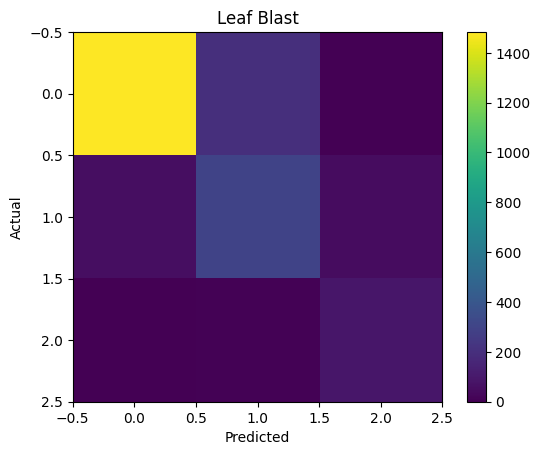

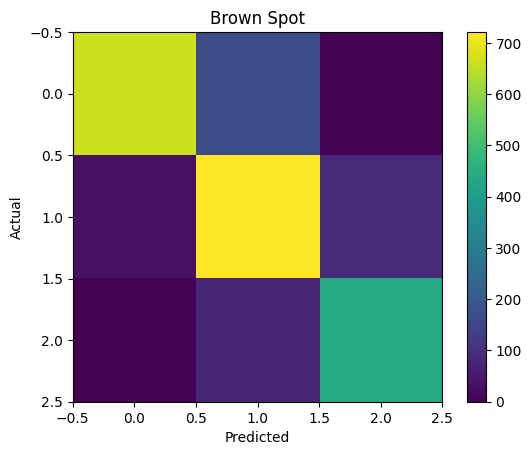

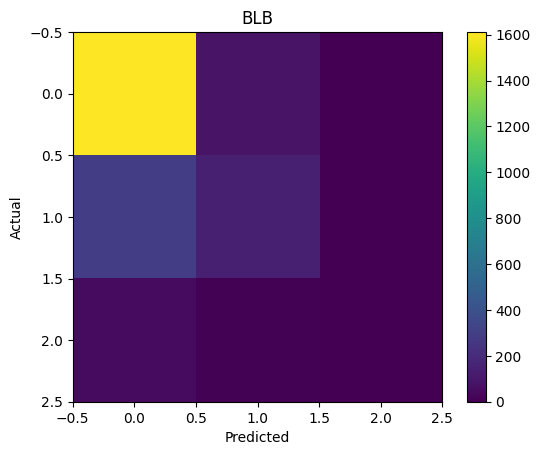

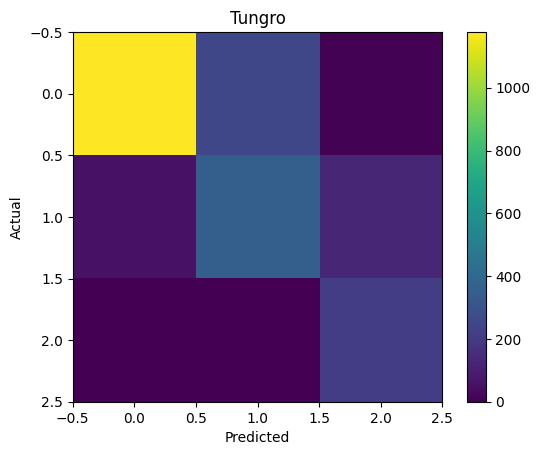

Model saved successfully


In [ ]:


# Backbone (unchanged)
inputs = layers.Input(shape=(7, X_train.shape[2]))

x = layers.Conv1D(64, kernel_size=3, activation="relu")(inputs)
x = layers.Conv1D(64, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# ===== NEW HEAD (multi-output) =====
leaf_blast = layers.Dense(3, activation="softmax", name="leaf_blast")(x)
brown_spot = layers.Dense(3, activation="softmax", name="brown_spot")(x)
blb = layers.Dense(3, activation="softmax", name="blb")(x)
tungro = layers.Dense(3, activation="softmax", name="tungro")(x)

model = Model(inputs=inputs, outputs=[
    leaf_blast, brown_spot, blb, tungro
])




# ================================
# 6. COMPILE
# ================================
model.compile(
    optimizer="adam",
    loss={
        "leaf_blast": "sparse_categorical_crossentropy",
        "brown_spot": "sparse_categorical_crossentropy",
        "blb": "sparse_categorical_crossentropy",
        "tungro": "sparse_categorical_crossentropy",
    },
    metrics={
        "leaf_blast": ["accuracy"],
        "brown_spot": ["accuracy"],
        "blb": ["accuracy"],
        "tungro": ["accuracy"],
    }
)

model.summary()

# ================================
# 7. TRAIN
# ================================
history = model.fit(
    X_train_scaled,
    {
        "leaf_blast": y_train_split[0],
        "brown_spot": y_train_split[1],
        "blb": y_train_split[2],
        "tungro": y_train_split[3],
    },
    validation_data=(
        X_test_scaled,
        {
            "leaf_blast": y_test_split[0],
            "brown_spot": y_test_split[1],
            "blb": y_test_split[2],
            "tungro": y_test_split[3],
        }
    ),
    epochs=20,
    batch_size=32
)

# ================================
# 8. PREDICT
# ================================
preds = model.predict(X_test_scaled)

# Convert probabilities → class labels
y_pred = [np.argmax(p, axis=1) for p in preds]

# ================================
# 9. EVALUATION
# ================================
diseases = ["Leaf Blast", "Brown Spot", "BLB", "Tungro"]

for i in range(4):
    print(f"\n--- {diseases[i]} ---")
    print(classification_report(y_test[:, i], y_pred[i]))

# ================================
# 10. ACCURACY PER DISEASE
# ================================
for i in range(4):
    acc = np.mean(y_pred[i] == y_test[:, i])
    print(f"{diseases[i]} Accuracy: {acc:.4f}")

# ================================
# 11. CONFUSION MATRIX
# ================================
for i in range(4):
    cm = confusion_matrix(y_test[:, i], y_pred[i])

    plt.figure()
    plt.imshow(cm)
    plt.title(diseases[i])
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ================================
# 12. SAVE MODEL
# ================================
model.save("paddy_tcn_multi_output.h5")
print("Model saved successfully")

In [ ]:
import joblib

# Save the Random Forest model
joblib.dump(model_rf, "random_forest_model.pkl")
print("Random Forest model saved as random_forest_model.pkl")

# Save the XGBoost model
joblib.dump(model_xgb, "xgboost_model.pkl")
print("XGBoost model saved as xgboost_model.pkl")


Random Forest model saved as random_forest_model.pkl
XGBoost model saved as xgboost_model.pkl


In [ ]:
import numpy as np
import joblib
import tensorflow as tf

# --- Load models ---
# Assuming these models are already trained and saved as per previous steps
model_rf = joblib.load("random_forest_model.pkl")
model_xgb = joblib.load("xgboost_model.pkl")
tcn_model = tf.keras.models.load_model("paddy_tcn_multi_output.h5")

# --- Define diseases and risk levels for interpretation ---
diseases = ["Leaf Blast", "Brown Spot", "BLB", "Tungro"]
risk_levels = ["Low", "Medium", "High"] # Assuming 0, 1, 2 for risk

# --- Create sample data for prediction ---
# We will use the first entry from the existing X_test sets for demonstration
# X_test_rf has shape (num_samples, WINDOW_SIZE * num_features)
# X_test_scaled has shape (num_samples, WINDOW_SIZE, num_features)

X_sample_rf_xgb = X_test_rf[0:1] # Take the first sample for RF/XGBoost
X_sample_tcn_scaled = X_test_scaled[0:1] # Take the first sample for TCN

print("--- Sample Data Predictions ---")

# --- Random Forest Prediction ---
rf_preds = model_rf.predict(X_sample_rf_xgb)
print("\nRandom Forest Predictions:")
for i, disease in enumerate(diseases):
    # rf_preds is (1, 4), each element is the predicted class (0, 1, or 2)
    risk_level_idx = int(rf_preds[0, i]) # Ensure it's an integer for indexing
    print(f"  {disease}: {risk_levels[risk_level_idx]}")

# --- XGBoost Prediction ---
xgb_preds = model_xgb.predict(X_sample_rf_xgb)
print("\nXGBoost Predictions:")
for i, disease in enumerate(diseases):
    # xgb_preds is (1, 4), each element is the predicted class (0, 1, or 2)
    risk_level_idx = int(xgb_preds[0, i]) # Ensure it's an integer for indexing
    print(f"  {disease}: {risk_levels[risk_level_idx]}")

# --- TCN Model Prediction ---
tcn_raw_preds = tcn_model.predict(X_sample_tcn_scaled, verbose=0)
print("\nTCN Model Predictions:")
# tcn_raw_preds is a list of 4 arrays, each (1, 3) representing probabilities for [0, 1, 2]
for i, disease in enumerate(diseases):
    risk_level_idx = np.argmax(tcn_raw_preds[i][0]) # Get the index of the max probability for the first sample
    print(f"  {disease}: {risk_levels[risk_level_idx]}")


--- Sample Data Predictions ---

Random Forest Predictions:
  Leaf Blast: Medium
  Brown Spot: Low
  BLB: Low
  Tungro: Medium

XGBoost Predictions:
  Leaf Blast: Medium
  Brown Spot: Low
  BLB: Low
  Tungro: Medium

TCN Model Predictions:
  Leaf Blast: Medium
  Brown Spot: Low
  BLB: Low
  Tungro: Medium


In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Load the models (assuming they are already saved)
model_rf = joblib.load("random_forest_model.pkl")
model_xgb = joblib.load("xgboost_model.pkl")
tcn_model = tf.keras.models.load_model("paddy_tcn_multi_output.h5")

# --- Define diseases and risk levels for interpretation ---
diseases = ["Leaf Blast", "Brown Spot", "BLB", "Tungro"]
risk_levels = ["Low", "Medium", "High"]

# --- Generate Synthetic Data ---
# The original X_train had shape (num_samples, WINDOW_SIZE, num_features)
# num_features is X_train.shape[2] which is 22
num_features = X_train.shape[2] # 22 features
window_size = 7 # WINDOW_SIZE

# Create a single synthetic sample for 7 days with 22 features.
# Generating random data, ensuring some values are within plausible ranges
# For simplicity, let's generate values that roughly mimic scaled data (mean ~0, std ~1)
# This is a placeholder; more realistic synthetic data generation would consider feature distributions
synthetic_data_3d = np.random.randn(1, window_size, num_features).astype(np.float32)

# Apply the same scaler used for X_train_scaled
# First, reshape the synthetic data to 2D for scaling
synthetic_data_2d_for_scaler = synthetic_data_3d.reshape(-1, num_features)

# Re-initialize and fit the scaler if not available in memory from previous runs
# For this example, we'll assume the scaler object from cell 'z_H6_Ggg24Wr' is available.
# If not, you'd need to load/re-fit it on representative data.

# If scaler is not in current kernel state, uncomment and execute the following lines:
# scaler = StandardScaler()
# X_train_2d = X_train.reshape(-1, X_train.shape[-1])
# scaler.fit(X_train_2d) # Fit on original training data

synthetic_data_scaled_2d = scaler.transform(synthetic_data_2d_for_scaler)
synthetic_data_scaled_3d = synthetic_data_scaled_2d.reshape(1, window_size, num_features)

# Prepare data for RF/XGBoost models (flattened)
synthetic_data_rf_xgb = synthetic_data_scaled_3d.reshape(1, -1)

print("--- Synthetic Data Predictions ---")

# --- Random Forest Prediction ---
rf_preds_synth = model_rf.predict(synthetic_data_rf_xgb)
print("\nRandom Forest Predictions (Synthetic Data):")
for i, disease in enumerate(diseases):
    risk_level_idx = int(rf_preds_synth[0, i])
    print(f"  {disease}: {risk_levels[risk_level_idx]}")

# --- XGBoost Prediction ---
xgb_preds_synth = model_xgb.predict(synthetic_data_rf_xgb)
print("\nXGBoost Predictions (Synthetic Data):")
for i, disease in enumerate(diseases):
    risk_level_idx = int(xgb_preds_synth[0, i])
    print(f"  {disease}: {risk_levels[risk_level_idx]}")

# --- TCN Model Prediction ---
tcn_raw_preds_synth = tcn_model.predict(synthetic_data_scaled_3d, verbose=0)
print("\nTCN Model Predictions (Synthetic Data):")
for i, disease in enumerate(diseases):
    risk_level_idx = np.argmax(tcn_raw_preds_synth[i][0])
    print(f"  {disease}: {risk_levels[risk_level_idx]}")


--- Synthetic Data Predictions ---

Random Forest Predictions (Synthetic Data):
  Leaf Blast: Low
  Brown Spot: Low
  BLB: Low
  Tungro: Low

XGBoost Predictions (Synthetic Data):
  Leaf Blast: Low
  Brown Spot: Low
  BLB: Low
  Tungro: Low

TCN Model Predictions (Synthetic Data):
  Leaf Blast: Low
  Brown Spot: Low
  BLB: Low
  Tungro: Low


In [ ]:
selected_district = "Nagapattinam" # @param ['Thanjavur', 'Nilgiris', 'Chennai', 'Virudhunagar', 'Nagapattinam']


In [ ]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry
import numpy as np

# Setup API client (using existing cache and retry logic)
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Forecast API URL
forecast_url = "https://api.open-meteo.com/v1/forecast"

# Get coordinates for the selected district
coord = locations[selected_district]

print(f"Fetching 7-day forecast for {selected_district}...")

# Define forecast parameters
params_forecast = {
    "latitude": coord["lat"],
    "longitude": coord["lon"],
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "wind_speed_10m_max"
    ],
    "forecast_days": 7, # Request 7 days of forecast
    "timezone": "auto",
}

responses_forecast = openmeteo.weather_api(forecast_url, params=params_forecast)
response_forecast = responses_forecast[0]

daily_forecast = response_forecast.Daily()

# Extract variables for forecast
data_forecast = {
    "date": pd.date_range(
        start=pd.to_datetime(daily_forecast.Time() + response_forecast.UtcOffsetSeconds(), unit="s", utc=True),
        end=pd.to_datetime(daily_forecast.TimeEnd() + response_forecast.UtcOffsetSeconds(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily_forecast.Interval()),
        inclusive="left"
    ),
    "temperature_mean": daily_forecast.Variables(0).ValuesAsNumpy(),
    "temperature_max": daily_forecast.Variables(1).ValuesAsNumpy(),
    "temperature_min": daily_forecast.Variables(2).ValuesAsNumpy(),
    "humidity": daily_forecast.Variables(3).ValuesAsNumpy(),
    "rainfall": daily_forecast.Variables(4).ValuesAsNumpy(),
    "wind_speed": daily_forecast.Variables(5).ValuesAsNumpy()
}

forecast_df = pd.DataFrame(data_forecast)
forecast_df["district"] = selected_district

print("Forecast data fetched successfully:")
display(forecast_df.head(7))

Fetching 7-day forecast for Nagapattinam...
Forecast data fetched successfully:


,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,district
0,2026-04-01 00:00:00+00:00,27.123251,31.504499,24.654501,76.041664,0.0,9.422101,Nagapattinam
1,2026-04-02 00:00:00+00:00,26.958664,32.604500,22.354500,78.083336,0.0,11.885453,Nagapattinam
2,2026-04-03 00:00:00+00:00,27.250334,33.054497,22.904501,81.958336,0.0,11.043261,Nagapattinam
3,2026-04-04 00:00:00+00:00,28.519089,33.454498,25.004499,82.125000,0.1,9.504272,Nagapattinam
4,2026-04-05 00:00:00+00:00,28.862831,32.254498,25.954500,83.875000,2.4,8.707238,Nagapattinam
5,2026-04-06 00:00:00+00:00,28.887833,32.954498,25.954500,85.083336,5.1,7.862518,Nagapattinam
6,2026-04-07 00:00:00+00:00,29.521166,34.654499,26.304501,83.125000,0.3,9.178235,Nagapattinam


In [ ]:
import numpy as np

# Load the existing historical dataframe to get the required preceding values for rolling features
# We'll use the last 5 days of the historical data for the selected district + the forecast data

# Filter historical data for the selected district using its one-hot encoded column.
# 'df' in the global scope has been one-hot encoded.
df_selected_district = df[df[f'district_{selected_district}'] == True].sort_values(by='date').copy()

# Extract the raw weather features and date for the historical window.
# The rolling and interaction features will be re-calculated on the combined historical+forecast data.
# Note: 'soil_moisture' is not included as it's not available in forecast data.
historical_raw_features = df_selected_district[[
    "date", "temperature_mean", "temperature_max", "temperature_min",
    "humidity", "rainfall", "wind_speed"
]].tail(WINDOW_SIZE-1).copy()
historical_raw_features['district'] = selected_district # Add back the district column for consistency with forecast_df

# Combine this raw historical window with the raw forecast data.
# This `combined_raw_df` will have a consistent 'district' column for all rows.
combined_raw_df = pd.concat([historical_raw_features, forecast_df], ignore_index=True)

# Ensure date is datetime and sorted
combined_raw_df['date'] = pd.to_datetime(combined_raw_df['date'])
combined_raw_df = combined_raw_df.sort_values(by="date").reset_index(drop=True)

# Apply feature engineering functions to combined_raw_df
# The `add_rolling_features_forecast` function correctly expects a 'district' column.
def add_rolling_features_forecast(df_in):
    df_out = df_in.copy()

    for district in df_out["district"].unique():
        mask = df_out["district"] == district

        # Temperature rolling
        df_out.loc[mask, "temp_avg_3d"] = df_out.loc[mask, "temperature_mean"].rolling(3).mean()
        df_out.loc[mask, "temp_avg_5d"] = df_out.loc[mask, "temperature_mean"].rolling(5).mean()

        # Humidity
        df_out.loc[mask, "humidity_avg_3d"] = df_out.loc[mask, "humidity"].rolling(3).mean()
        df_out.loc[mask, "humidity_avg_5d"] = df_out.loc[mask, "humidity"].rolling(5).mean()

        # Rainfall
        df_out.loc[mask, "rainfall_sum_3d"] = df_out.loc[mask, "rainfall"].rolling(3).sum()
        df_out.loc[mask, "rainfall_sum_5d"] = df_out.loc[mask, "rainfall"].rolling(5).sum()

    return df_out

forecast_features_df = add_rolling_features_forecast(combined_raw_df)

# Add interaction features
forecast_features_df["temp_humidity"] = forecast_features_df["temperature_mean"] * forecast_features_df["humidity"]
forecast_features_df["rainfall_humidity"] = forecast_features_df["rainfall"] * forecast_features_df["humidity"]

# Add time-based features
forecast_features_df["month"] = forecast_features_df["date"].dt.month
forecast_features_df["day_of_year"] = forecast_features_df["date"].dt.dayofyear

# Keep only the forecast days (the last 7 rows)
forecast_features_df = forecast_features_df.tail(7).reset_index(drop=True)

print("Forecast data with engineered features:")
display(forecast_features_df.head(7))

Forecast data with engineered features:


,date,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,district,temp_avg_3d,temp_avg_5d,humidity_avg_3d,humidity_avg_5d,rainfall_sum_3d,rainfall_sum_5d,temp_humidity,rainfall_humidity,month,day_of_year
0,2026-04-01 00:00:00+00:00,27.123251,31.504499,24.654501,76.041664,0.0,9.422101,Nagapattinam,25.839695,25.593816,81.719621,80.582611,4.3,5.3,2062.497140,0.000000,4,91
1,2026-04-02 00:00:00+00:00,26.958664,32.604500,22.354500,78.083336,0.0,11.885453,Nagapattinam,26.402999,25.964299,80.748623,80.459140,4.3,5.0,2105.022411,0.000000,4,92
2,2026-04-03 00:00:00+00:00,27.250334,33.054497,22.904501,81.958336,0.0,11.043261,Nagapattinam,27.110750,26.345617,78.694445,81.040107,0.0,4.3,2233.392009,0.000000,4,93
3,2026-04-04 00:00:00+00:00,28.519089,33.454498,25.004499,82.125000,0.1,9.504272,Nagapattinam,27.576029,26.995684,80.722224,81.265841,0.1,4.4,2342.130163,8.212500,4,94
4,2026-04-05 00:00:00+00:00,28.862831,32.254498,25.954500,83.875000,2.4,8.707238,Nagapattinam,28.210751,27.742834,82.652779,80.416667,2.5,2.5,2420.869960,201.300008,4,95
5,2026-04-06 00:00:00+00:00,28.887833,32.954498,25.954500,85.083336,5.1,7.862518,Nagapattinam,28.756584,28.095750,83.694445,82.225002,7.6,7.6,2457.873167,433.925045,4,96
6,2026-04-07 00:00:00+00:00,29.521166,34.654499,26.304501,83.125000,0.3,9.178235,Nagapattinam,29.090610,28.608250,84.027779,83.233334,7.8,7.9,2453.946911,24.937501,4,97


In [ ]:
# One-hot encode the district for the forecast data
# Ensure all possible district columns from training are present, even if false

# Create a dummy DataFrame with all district columns expected by the model
all_district_cols = [col for col in feature_cols if "district_" in col]

dummy_df = pd.DataFrame(0, index=forecast_features_df.index, columns=all_district_cols)

# Set the column corresponding to the selected_district to 1
dummy_df[f'district_{selected_district}'] = 1

# Concatenate with the forecast_features_df
forecast_processed_df = pd.concat([forecast_features_df.drop(columns=['district']), dummy_df], axis=1)

# Drop date column, as it's not a feature for prediction
forecast_processed_df = forecast_processed_df.drop(columns=['date'])

print("Forecast data after one-hot encoding:")
display(forecast_processed_df.head(7))


Forecast data after one-hot encoding:


,temperature_mean,temperature_max,temperature_min,humidity,rainfall,wind_speed,temp_avg_3d,temp_avg_5d,humidity_avg_3d,humidity_avg_5d,...,rainfall_sum_5d,temp_humidity,rainfall_humidity,month,day_of_year,district_Chennai,district_Nagapattinam,district_Nilgiris,district_Thanjavur,district_Virudhunagar
0,27.123251,31.504499,24.654501,76.041664,0.0,9.422101,25.839695,25.593816,81.719621,80.582611,...,5.3,2062.497140,0.000000,4,91,0,1,0,0,0
1,26.958664,32.604500,22.354500,78.083336,0.0,11.885453,26.402999,25.964299,80.748623,80.459140,...,5.0,2105.022411,0.000000,4,92,0,1,0,0,0
2,27.250334,33.054497,22.904501,81.958336,0.0,11.043261,27.110750,26.345617,78.694445,81.040107,...,4.3,2233.392009,0.000000,4,93,0,1,0,0,0
3,28.519089,33.454498,25.004499,82.125000,0.1,9.504272,27.576029,26.995684,80.722224,81.265841,...,4.4,2342.130163,8.212500,4,94,0,1,0,0,0
4,28.862831,32.254498,25.954500,83.875000,2.4,8.707238,28.210751,27.742834,82.652779,80.416667,...,2.5,2420.869960,201.300008,4,95,0,1,0,0,0
5,28.887833,32.954498,25.954500,85.083336,5.1,7.862518,28.756584,28.095750,83.694445,82.225002,...,7.6,2457.873167,433.925045,4,96,0,1,0,0,0
6,29.521166,34.654499,26.304501,83.125000,0.3,9.178235,29.090610,28.608250,84.027779,83.233334,...,7.9,2453.946911,24.937501,4,97,0,1,0,0,0


In [ ]:
import numpy as np

# Ensure feature columns match the order and names from training
X_forecast_raw = forecast_processed_df[feature_cols].values

# Reshape to 3D for scaling (num_samples, 1, num_features)
X_forecast_3d = X_forecast_raw.reshape(-1, 1, len(feature_cols))

# Flatten for scaling: (num_samples * WINDOW_SIZE, num_features)
X_forecast_2d_for_scaler = X_forecast_3d.reshape(-1, X_forecast_3d.shape[-1])

# Scale using the *fitted* scaler
X_forecast_scaled_2d = scaler.transform(X_forecast_2d_for_scaler)

# Reshape back to 3D for TCN model: (num_samples, WINDOW_SIZE, num_features)
X_forecast_scaled = X_forecast_scaled_2d.reshape(X_forecast_3d.shape)

# For RF/XGBoost, we need sequences of WINDOW_SIZE, so we need to create them.
# Given we have 7 days of forecast, and WINDOW_SIZE is 7, we will have 1 sequence for RF/XGBoost.

# Pad with previous days if not enough historical data for full window
if len(X_forecast_scaled) < WINDOW_SIZE:
    # This scenario is handled by concatenating historical data earlier.
    # For direct forecast, we expect 7 days, so if WINDOW_SIZE is 7, this will be one full window.
    # For the purpose of prediction, we take the entire 7-day sequence.
    pass

X_forecast_rf_xgb = X_forecast_scaled.reshape(1, -1) # Flatten the single 7-day sequence for RF/XGBoost

print("Forecast data prepared for prediction. Shapes:")
print("X_forecast_rf_xgb shape:", X_forecast_rf_xgb.shape)
print("X_forecast_scaled (for TCN) shape:", X_forecast_scaled.shape)


Forecast data prepared for prediction. Shapes:
X_forecast_rf_xgb shape: (1, 147)
X_forecast_scaled (for TCN) shape: (7, 1, 21)


In [ ]:
import numpy as np
import joblib
import tensorflow as tf

# Load models (if not already in memory)
model_rf = joblib.load("random_forest_model.pkl")
model_xgb = joblib.load("xgboost_model.pkl")
tcn_model = tf.keras.models.load_model("paddy_tcn_multi_output.h5")

# --- Define diseases and risk levels for interpretation ---
diseases = ["Leaf Blast", "Brown Spot", "BLB", "Tungro"]
risk_levels = ["Low", "Medium", "High"]

print(f"\n--- 7-Day Risk Forecast for {selected_district} ---")

# Initialize lists to store predictions for each day and model
rf_daily_preds = []
xgb_daily_preds = []
tcn_daily_preds = []

# We have 7 days of forecast data. Each model makes a prediction for the *next* day (day 7 if input is day 1-6).
# Since our current X_forecast_scaled and X_forecast_rf_xgb already represent a WINDOW_SIZE=7 sequence
# for predicting the 8th day, we will make one prediction per model.
# To get a 7-day forecast, we need to iterate over rolling windows if we want daily predictions.

# Re-create sequences to get predictions for each of the 7 forecast days
# For each day in the 7-day forecast, we want a prediction. This implies
# we need to consider 'WINDOW_SIZE' days leading up to each forecast day.
# However, our current setup provides a single WINDOW_SIZE=7 input to predict a single 'next' day.
# To get predictions for the entire 7-day forecast, we need to apply the model for each day within that window.

# Let's adjust to generate predictions for each of the 7 forecast days.
# This means we need 7 different input sequences, each of WINDOW_SIZE = 7.
# The `X_forecast_scaled` is already a 7-day sequence of features.
# To get individual daily predictions, we'd need to assume each row in `X_forecast_scaled` (if we reshaped it)
# represents the 'future' day, and its preceding WINDOW_SIZE-1 days are also included.

# Let's revise: We have a `forecast_processed_df` of 7 days. Each row is a day's features. We want 7 predictions.
# For the first day's prediction (e.g., day 1 of forecast), we would need a sequence of (WINDOW_SIZE - 1) historical days + day 1 forecast.
# For the second day's prediction (e.g., day 2 of forecast), we would need a sequence of (WINDOW_SIZE - 2) historical days + day 1 & 2 forecast.
# This requires building multiple sequences.

print("Genera ting daily risk predictions for the next 7 days:")

for day_idx in range(7):
    print(f"\nDay {day_idx + 1} ({forecast_features_df['date'].iloc[day_idx].strftime('%Y-%m-%d')}):")

    # For each day_idx (0 to 6), we need a WINDOW_SIZE (7) length sequence ending at this day.
    # This sequence will consist of a mix of historical and forecast data.
    # `combined_raw_df` already contains `WINDOW_SIZE-1` historical days + 7 forecast days.
    # So, `combined_raw_df` has `(WINDOW_SIZE-1) + 7` rows.

    # Extract relevant portion of combined_raw_df for this day's sequence
    # The sequence for predicting risk on `day_idx` of forecast would be `WINDOW_SIZE` days ending on `forecast_features_df.iloc[day_idx]`

    # Create a sub-dataframe for the current window for prediction
    current_window_df = combined_raw_df.iloc[day_idx : day_idx + WINDOW_SIZE].copy()

    # Apply feature engineering to this specific window.
    # Re-computing rolling features for each window is important.
    current_window_df = add_rolling_features_forecast(current_window_df) # This func is already defined above

    # Add interaction features
    current_window_df["temp_humidity"] = current_window_df["temperature_mean"] * current_window_df["humidity"]
    current_window_df["rainfall_humidity"] = current_window_df["rainfall"] * current_window_df["humidity"]

    # Add time-based features
    current_window_df["month"] = current_window_df["date"].dt.month
    current_window_df["day_of_year"] = current_window_df["date"].dt.dayofyear

    # One-hot encode district for this window
    dummy_window_df = pd.DataFrame(0, index=current_window_df.index, columns=all_district_cols)
    dummy_window_df[f'district_{selected_district}'] = 1
    current_window_processed_df = pd.concat([current_window_df.drop(columns=['district']), dummy_window_df], axis=1)
    current_window_processed_df = current_window_processed_df.drop(columns=['date'])

    # Get the full WINDOW_SIZE sequence for RF/XGBoost and TCN
    X_window_raw = current_window_processed_df[feature_cols].values # Shape (WINDOW_SIZE, num_features)

    # Scale the window data
    X_window_scaled = scaler.transform(X_window_raw)

    # Reshape for models
    # For RF/XGBoost: Flatten the WINDOW_SIZE sequence into a single row
    X_pred_rf_xgb = X_window_scaled.reshape(1, -1) # Shape (1, WINDOW_SIZE * num_features)

    # For TCN: Reshape to (1, WINDOW_SIZE, num_features)
    X_pred_tcn = X_window_scaled.reshape(1, WINDOW_SIZE, len(feature_cols))

    # --- Make Predictions ---
    rf_pred = model_rf.predict(X_pred_rf_xgb)
    xgb_pred = model_xgb.predict(X_pred_rf_xgb)
    tcn_raw_pred = tcn_model.predict(X_pred_tcn, verbose=0)

    # Interpret and print results for the current day
    print("  Random Forest:")
    for i, disease in enumerate(diseases):
        print(f"    {disease}: {risk_levels[int(rf_pred[0, i])] } ")

    print("  XGBoost:")
    for i, disease in enumerate(diseases):
        print(f"    {disease}: {risk_levels[int(xgb_pred[0, i])] } ")

    print("  TCN Model:")
    for i, disease in enumerate(diseases):
        tcn_risk_level = np.argmax(tcn_raw_pred[i][0])
        print(f"    {disease}: {risk_levels[tcn_risk_level]}")


--- 7-Day Risk Forecast for Nagapattinam ---
Genera ting daily risk predictions for the next 7 days:

Day 1 (2026-04-01):


  Random Forest:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: Low 
  XGBoost:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: Low 
  TCN Model:
    Leaf Blast: Low
    Brown Spot: Low
    BLB: Low
    Tungro: Low

Day 2 (2026-04-02):
  Random Forest:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: Low 
  XGBoost:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: Low 
  TCN Model:
    Leaf Blast: Low
    Brown Spot: Low
    BLB: Low
    Tungro: Low

Day 3 (2026-04-03):
  Random Forest:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: Low 
  XGBoost:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: Low 
  TCN Model:
    Leaf Blast: Low
    Brown Spot: Low
    BLB: Low
    Tungro: Low

Day 4 (2026-04-04):
  Random Forest:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: Low 
  XGBoost:
    Leaf Blast: Low 
    Brown Spot: Low 
    BLB: Low 
    Tungro: 

In [ ]:
from google.colab import files

# List of model files to download
model_files = [
    "random_forest_model.pkl",
    "xgboost_model.pkl",
    "paddy_lstm_multi_output.h5", # LSTM model
    "paddy_gnn_multi_output.h5",  # GRU-based model, named gnn
    "paddy_tcn_multi_output.h5"   # TCN model
]

print("Initiating download for all trained models...")

for filename in model_files:
    try:
        files.download(filename)
        print(f"Downloaded: {filename}")
    except FileNotFoundError:
        print(f"Error: {filename} not found. Make sure the model was saved correctly.")
    except Exception as e:
        print(f"An error occurred while downloading {filename}: {e}")

print("Download process complete.")

Initiating download for all trained models...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: random_forest_model.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: paddy_gnn_multi_output.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: paddy_tcn_multi_output.h5
Download process complete.
